# Does ChatGPT Use Cause Lower Exam Scores?

## Motivation

Wecks et al. (ECIS 2025 / [arXiv:2404.19699](https://arxiv.org/abs/2404.19699)) analyzed 193 university students whose ChatGPT usage was inferred from submitted essays using AI-detection tools.
They dentified ChatGPT users scored **6.71 points lower** on a subsequent exam.

> **Does ChatGPT use cause students to perform worse on exams?**

---

> **Note:** The analysis below uses a **hypothetical synthetic population of 600 students**. It is not a reproduction, reanalysis, or critique of the Wecks study.

## Our hypothetical research experiment

- ChatGPT is generally available to every student.
- Assume usage is not encouraged/assigned (forward pointer to IV).
- Researchers later observe usage and compared groups (post-hoc analysis).

- **`genai_user = 1`** &nbsp; self-selected into regular ChatGPT use during coursework
- **`genai_user = 0`** &nbsp; did not regularly use ChatGPT

The causal question: *for the same student, how would exam performance differ if they had used ChatGPT versus not?* We never observe both outcomes for the same student — this is the **fundamental problem of causal inference**.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import statsmodels.formula.api as smf

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
np.random.seed(42)
N = 600

C_USER  = '#C8102E'   # red  — ChatGPT user
C_NUSER = '#4878CF'   # blue — non-user

# ── Baseline preparedness (0–100) ──────────────────────────────────────────
# Captures prior knowledge, study habits, and motivation
preparedness = np.clip(np.random.normal(60, 15, N), 5, 95)

# ── Self-selection into ChatGPT use ────────────────────────────────────────
# Less-prepared students are more likely to reach for ChatGPT
p_use      = 1 / (1 + np.exp(-(2.0 - 0.05 * preparedness)))
genai_user = np.random.binomial(1, p_use)

# ── Exam score ─────────────────────────────────────────────────────────────
# Driven by preparedness; ChatGPT has ZERO causal effect
# True world model + noise
exam_score = np.clip(
    18 + 0.85 * preparedness + np.random.normal(0, 8, N), 0, 100
)


# ── Assignment completion time (hours) ─────────────────────────────────────
# Preparedness reduces time; ChatGPT genuinely reduces time (causal effect)
completion_time = np.clip(
    5.0 - 0.03 * preparedness - 1.5 * genai_user + np.random.normal(0, 0.6, N),
    0.3, None
)

df = pd.DataFrame({
    'student_id':            np.arange(1, N + 1),
    'baseline_preparedness': preparedness.round(1),
    'genai_user':            genai_user,
    'exam_score':            exam_score.round(1),
    'completion_time':       completion_time.round(2),
})

# ── Diagnostic summary ─────────────────────────────────────────────────────
pct_users = genai_user.mean() * 100
raw_gap   = df.groupby('genai_user')['exam_score'].mean().diff().iloc[-1]
clip_lo   = (exam_score == 0).mean()   * 100
clip_hi   = (exam_score == 100).mean() * 100

print(f"N = {N} students")
print(f"ChatGPT users:   {pct_users:.1f}%    (target 25–40%)")
print(f"Raw exam gap:    {raw_gap:+.2f} pts   (target −6 to −8)")

N = 600 students
ChatGPT users:   29.8%    (target 25–40%)
Raw exam gap:    -6.31 pts   (target −6 to −8)


In [13]:
df

,student_id,baseline_preparedness,genai_user,exam_score,completion_time
0,1,67.5,0,81.5,3.77
1,2,57.9,1,44.4,1.69
2,3,69.7,0,86.4,1.64
3,4,82.8,0,74.5,2.15
4,5,56.5,0,63.1,4.08
...,...,...,...,...,...
595,596,52.3,0,60.1,3.65
596,597,56.0,1,66.9,2.35
597,598,45.3,0,67.1,3.39
598,599,53.3,0,55.3,1.84


---
## A. What Do We Observe?

We begin with only two variables: ChatGPT usage and exam score. This is the view any observational researcher would have before digging deeper.

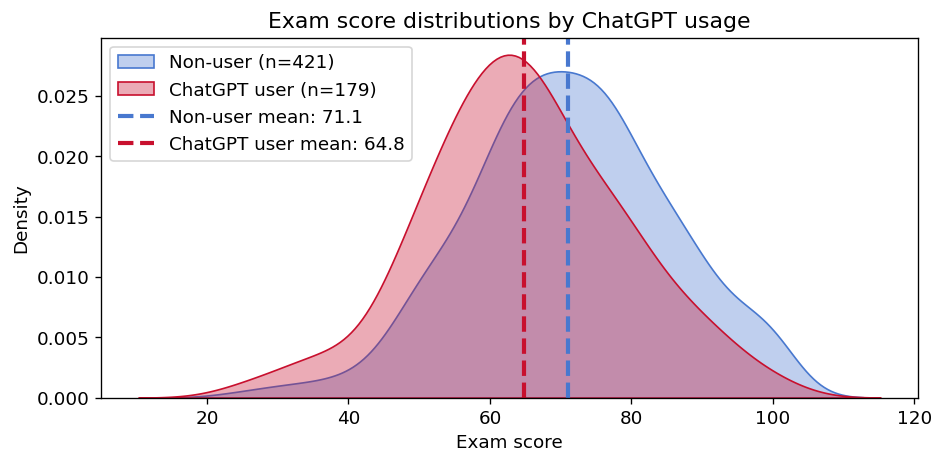

Non-user mean:     71.1
ChatGPT user mean: 64.8
Raw difference:    -6.3 points


In [4]:
users    = df[df['genai_user'] == 1]['exam_score']
nonusers = df[df['genai_user'] == 0]['exam_score']

fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(nonusers, ax=ax, color=C_NUSER, fill=True, alpha=0.35,
            label=f'Non-user (n={len(nonusers)})')
sns.kdeplot(users,    ax=ax, color=C_USER,  fill=True, alpha=0.35,
            label=f'ChatGPT user (n={len(users)})')
ax.axvline(nonusers.mean(), color=C_NUSER, lw=2.5, ls='--',
           label=f'Non-user mean: {nonusers.mean():.1f}')
ax.axvline(users.mean(),    color=C_USER,  lw=2.5, ls='--',
           label=f'ChatGPT user mean: {users.mean():.1f}')
ax.set_xlabel('Exam score')
ax.set_ylabel('Density')
ax.set_title('Exam score distributions by ChatGPT usage')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Non-user mean:     {nonusers.mean():.1f}")
print(f"ChatGPT user mean: {users.mean():.1f}")
print(f"Raw difference:    {users.mean() - nonusers.mean():+.1f} points")

### Unadjusted regression

We first fit the model:

$$
\text{ExamScore}_i = \beta_0 + \beta_1 \text{GenAIUser}_i + \epsilon_i
$$

where $\beta_1$ captures the difference in expected exam score between GenAI users and non-users.

In [5]:
m_unadj  = smf.ols('exam_score ~ genai_user', data=df).fit()
coef     = m_unadj.params['genai_user']
lo, hi   = m_unadj.conf_int().loc['genai_user']
p        = m_unadj.pvalues['genai_user']
print("Unadjusted regression: exam_score ~ genai_user")
print(f"  ChatGPT coefficient: {coef:.2f}  95% CI [{lo:.2f}, {hi:.2f}]  p = {p:.4f}")

Unadjusted regression: exam_score ~ genai_user
  ChatGPT coefficient: -6.31  95% CI [-8.81, -3.81]  p = 0.0000


> **Pause and predict:** ChatGPT users scored about seven points lower. What could explain this difference? Does this comparison tell us anything about the *effect* of using ChatGPT?

---
## B. Were Users and Non-Users Comparable?

The raw comparison treats the two groups as if they were exchangeable — as if we had flipped a coin to decide who used ChatGPT. But they weren't assigned. They chose.

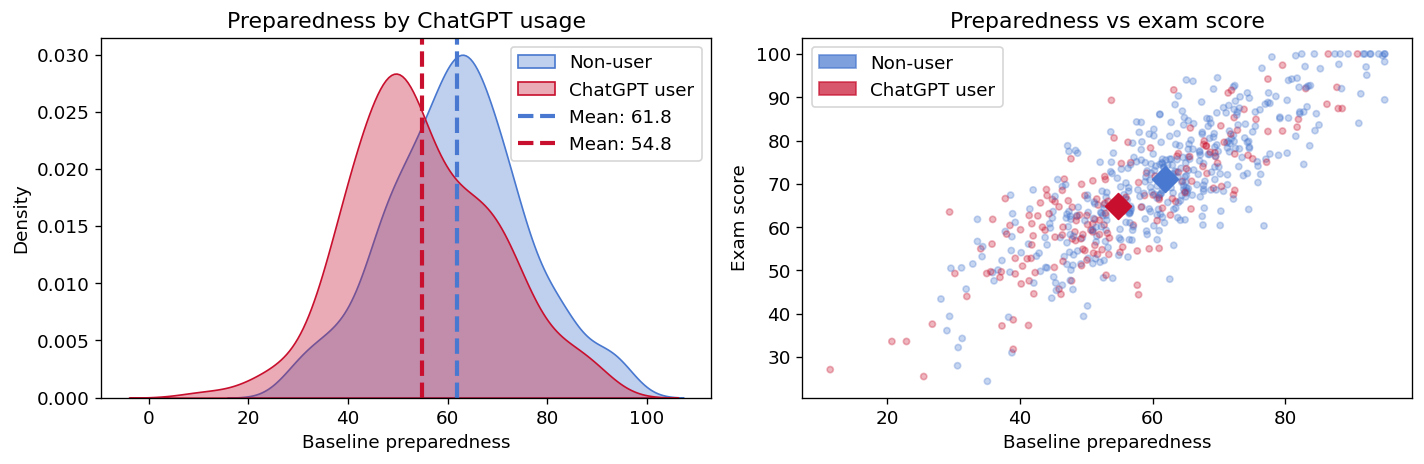

Mean preparedness — Non-user: 61.8,  ChatGPT user: 54.8


In [6]:
prep_u = df[df['genai_user'] == 1]['baseline_preparedness']
prep_n = df[df['genai_user'] == 0]['baseline_preparedness']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: preparedness distributions by group
sns.kdeplot(prep_n, ax=axes[0], color=C_NUSER, fill=True, alpha=0.35, label='Non-user')
sns.kdeplot(prep_u, ax=axes[0], color=C_USER,  fill=True, alpha=0.35, label='ChatGPT user')
axes[0].axvline(prep_n.mean(), color=C_NUSER, lw=2.5, ls='--', label=f'Mean: {prep_n.mean():.1f}')
axes[0].axvline(prep_u.mean(), color=C_USER,  lw=2.5, ls='--', label=f'Mean: {prep_u.mean():.1f}')
axes[0].set_xlabel('Baseline preparedness')
axes[0].set_ylabel('Density')
axes[0].set_title('Preparedness by ChatGPT usage')
axes[0].legend()

# Right: preparedness vs exam score, colored by group
c_map = df['genai_user'].map({0: C_NUSER, 1: C_USER})
axes[1].scatter(df['baseline_preparedness'], df['exam_score'],
                c=c_map, alpha=0.3, s=14)
axes[1].scatter([prep_n.mean()], [nonusers.mean()], color=C_NUSER,
                s=120, zorder=5, marker='D', label='Non-user mean')
axes[1].scatter([prep_u.mean()], [users.mean()],    color=C_USER,
                s=120, zorder=5, marker='D', label='ChatGPT user mean')
axes[1].legend(handles=[
    mpatches.Patch(color=C_NUSER, alpha=0.7, label='Non-user'),
    mpatches.Patch(color=C_USER,  alpha=0.7, label='ChatGPT user'),
])
axes[1].set_xlabel('Baseline preparedness')
axes[1].set_ylabel('Exam score')
axes[1].set_title('Preparedness vs exam score')

plt.tight_layout()
plt.show()

print(f"Mean preparedness — Non-user: {prep_n.mean():.1f},  ChatGPT user: {prep_u.mean():.1f}")

**Baseline preparedness is a confounder** — it influences both whether a student chooses to use ChatGPT *and* how well they perform on the exam.

```
Baseline preparedness ──► ChatGPT use
         │
         └───────────────► Exam score

ChatGPT use  ─ ─ ─ ─ ─ ─► Exam score   (← what we want to know)
```

The raw comparison conflates the effect of ChatGPT with the pre-existing differences between students who chose to use it and those who did not.

---
## C. Controlling for Preparedness

Instead of comparing all users to all non-users, compare students at similar levels of preparedness. Within each band, the two groups are more alike.

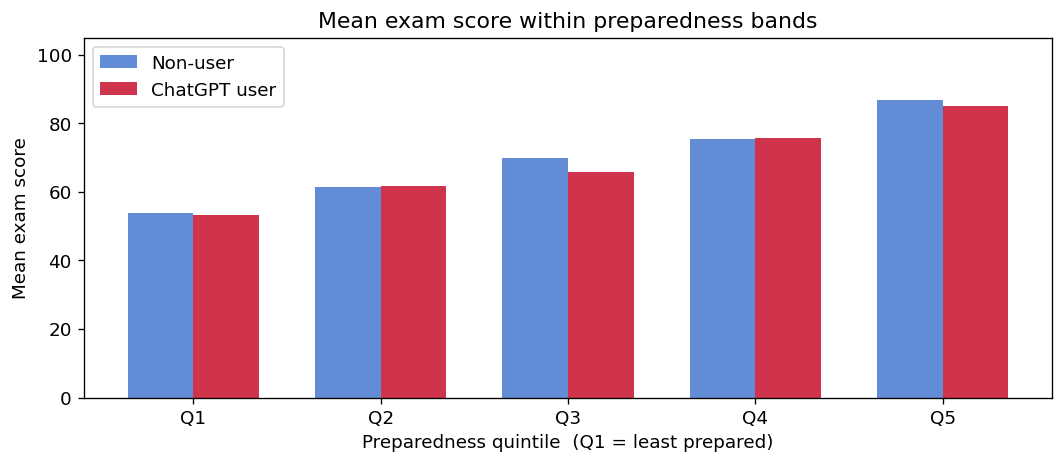

genai_user  Non-user  ChatGPT user  Within-band gap
prep_band                                          
Q1              53.8          53.2             -0.6
Q2              61.4          61.6              0.3
Q3              70.0          65.9             -4.2
Q4              75.5          75.7              0.2
Q5              86.9          85.0             -1.9


In [7]:
df['prep_band'] = pd.qcut(df['baseline_preparedness'], q=5,
                           labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])

band_stats = (df.groupby(['prep_band', 'genai_user'], observed=True)['exam_score']
                .mean().unstack('genai_user')
                .rename(columns={0: 'Non-user', 1: 'ChatGPT user'}))
band_stats['Within-band gap'] = (band_stats['ChatGPT user'] - band_stats['Non-user']).round(1)
band_stats[['Non-user', 'ChatGPT user']] = band_stats[['Non-user', 'ChatGPT user']].round(1)

x = np.arange(len(band_stats))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, band_stats['Non-user'],     w, color=C_NUSER, alpha=0.85, label='Non-user')
ax.bar(x + w/2, band_stats['ChatGPT user'], w, color=C_USER,  alpha=0.85, label='ChatGPT user')
ax.set_xticks(x)
ax.set_xticklabels([f'{b}' for b in band_stats.index])
ax.set_xlabel('Preparedness quintile  (Q1 = least prepared)')
ax.set_ylabel('Mean exam score')
ax.set_title('Mean exam score within preparedness bands')
ax.legend()
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

print(band_stats.to_string())

### Adjusting for baseline preparedness

The unadjusted regression compared ChatGPT users with non-users:

$$
\text{ExamScore}_i
=
\beta_0
+
\beta_1 \text{GenAIUser}_i
+
\epsilon_i
$$

Now we control for baseline preparedness:

$$
\text{ExamScore}_i
=
\beta_0
+
\beta_1 \text{GenAIUser}_i
+
\beta_2 \text{Preparedness}_i
+
\epsilon_i
$$

Here, $\beta_1$ compares ChatGPT users and non-users **holding baseline preparedness constant**.

In [8]:
m_adj = smf.ols('exam_score ~ genai_user + baseline_preparedness', data=df).fit()

def reg_row(model, label):
    c      = model.params['genai_user']
    lo, hi = model.conf_int().loc['genai_user']
    p      = model.pvalues['genai_user']
    return {'Analysis': label,
            'ChatGPT coef (pts)': round(c, 2),
            '95% CI': f'[{lo:.2f}, {hi:.2f}]',
            'p-value': round(p, 3)}

results = pd.DataFrame([
    reg_row(m_unadj, 'Unadjusted'),
    reg_row(m_adj,   'Controlling for preparedness'),
])
print("Exam score — regression results:")
print(results.to_string(index=False))
print()
print("In this simulated population, ChatGPT did not lower exam scores.")
print("Baseline preparedness generated the observed gap between groups.")

Exam score — regression results:
                    Analysis  ChatGPT coef (pts)         95% CI  p-value
                  Unadjusted               -6.31 [-8.81, -3.81]    0.000
Controlling for preparedness               -0.42  [-1.87, 1.04]    0.574

In this simulated population, ChatGPT did not lower exam scores.
Baseline preparedness generated the observed gap between groups.


---
## Contrast: Does ChatGPT Reduce Assignment Completion Time?

Same students. Same self-selection mechanism. Same confounder. Now consider a different outcome: **hours to complete a course assignment**.

ChatGPT plausibly speeds up drafting, checking work, and iterating — so it may have a **genuine causal effect** on time. Does controlling for preparedness erase this relationship too?

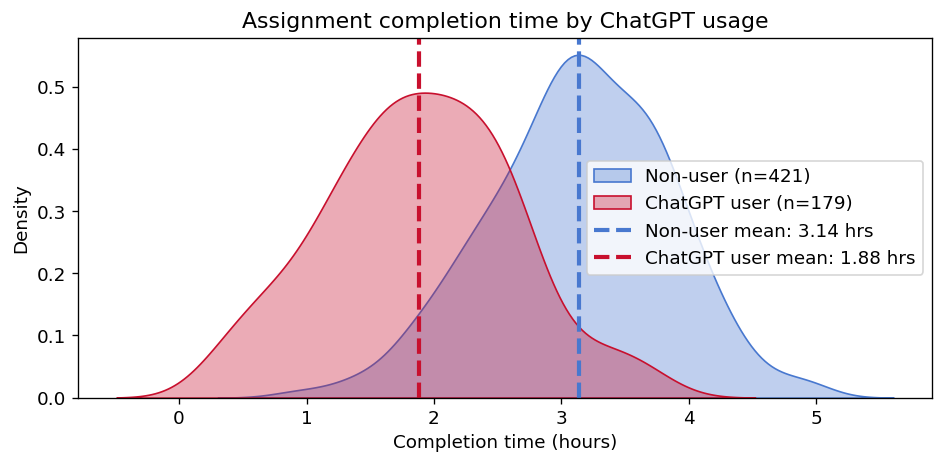

Non-user mean:     3.14 hrs
ChatGPT user mean: 1.88 hrs
Raw difference:    -1.25 hrs


In [9]:
ct_users    = df[df['genai_user'] == 1]['completion_time']
ct_nonusers = df[df['genai_user'] == 0]['completion_time']

fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(ct_nonusers, ax=ax, color=C_NUSER, fill=True, alpha=0.35,
            label=f'Non-user (n={len(ct_nonusers)})')
sns.kdeplot(ct_users,    ax=ax, color=C_USER,  fill=True, alpha=0.35,
            label=f'ChatGPT user (n={len(ct_users)})')
ax.axvline(ct_nonusers.mean(), color=C_NUSER, lw=2.5, ls='--',
           label=f'Non-user mean: {ct_nonusers.mean():.2f} hrs')
ax.axvline(ct_users.mean(),    color=C_USER,  lw=2.5, ls='--',
           label=f'ChatGPT user mean: {ct_users.mean():.2f} hrs')
ax.set_xlabel('Completion time (hours)')
ax.set_ylabel('Density')
ax.set_title('Assignment completion time by ChatGPT usage')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Non-user mean:     {ct_nonusers.mean():.2f} hrs")
print(f"ChatGPT user mean: {ct_users.mean():.2f} hrs")
print(f"Raw difference:    {ct_users.mean() - ct_nonusers.mean():+.2f} hrs")

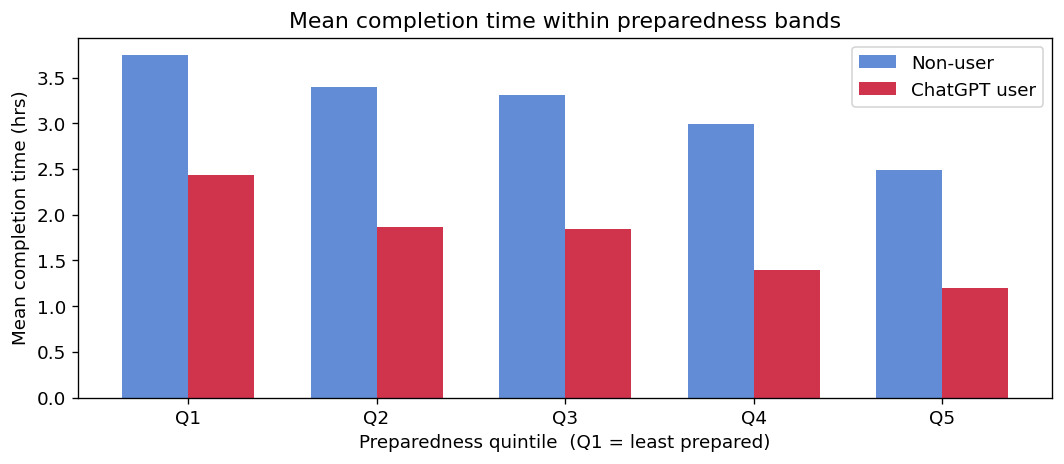

genai_user  Non-user  ChatGPT user  Within-band gap
prep_band                                          
Q1              3.75          2.43            -1.31
Q2              3.40          1.87            -1.52
Q3              3.31          1.84            -1.47
Q4              2.99          1.40            -1.58
Q5              2.49          1.20            -1.29


In [10]:
ct_band = (df.groupby(['prep_band', 'genai_user'], observed=True)['completion_time']
             .mean().unstack('genai_user')
             .rename(columns={0: 'Non-user', 1: 'ChatGPT user'}))
ct_band['Within-band gap'] = (ct_band['ChatGPT user'] - ct_band['Non-user']).round(2)
ct_band[['Non-user', 'ChatGPT user']] = ct_band[['Non-user', 'ChatGPT user']].round(2)

x = np.arange(len(ct_band))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, ct_band['Non-user'],     w, color=C_NUSER, alpha=0.85, label='Non-user')
ax.bar(x + w/2, ct_band['ChatGPT user'], w, color=C_USER,  alpha=0.85, label='ChatGPT user')
ax.set_xticks(x)
ax.set_xticklabels([f'{b}' for b in ct_band.index])
ax.set_xlabel('Preparedness quintile  (Q1 = least prepared)')
ax.set_ylabel('Mean completion time (hrs)')
ax.set_title('Mean completion time within preparedness bands')
ax.legend()
plt.tight_layout()
plt.show()

print(ct_band.to_string())

In [11]:
summary = pd.DataFrame([
    {
        'Outcome':              'Exam score',
        'Raw gap (all students)': f'{users.mean() - nonusers.mean():+.1f} pts',
        'Within-band gaps':     'Near zero in every quintile',
        'Verdict':              'Gap disappears  →  confounding',
    },
    {
        'Outcome':              'Completion time',
        'Raw gap (all students)': f'{ct_users.mean() - ct_nonusers.mean():+.2f} hrs',
        'Within-band gaps':     'Persists in every quintile',
        'Verdict':              'Gap persists    →  likely causal',
    },
])
print(summary.to_string(index=False))

        Outcome Raw gap (all students)            Within-band gaps                          Verdict
     Exam score               -6.3 pts Near zero in every quintile   Gap disappears  →  confounding
Completion time              -1.25 hrs  Persists in every quintile Gap persists    →  likely causal


---
## D. What Did We Learn?

1. **The raw association was genuine:** ChatGPT users really did score lower in the observed data.
2. **The association was not causal** (for exam scores): in this simulated world, baseline preparedness generated the entire gap.
3. **Preparedness was a confounder:** it affected both self-selected ChatGPT usage and exam performance.
4. **The same control had different effects on different outcomes:** it erased the exam score gap (confounding) but left the completion time gap intact (likely causal).

> **Why does this matter?** This demonstration is decisive because *we generated the data* and know the truth. In real observational research, we must justify whether the important confounders were measured and modeled adequately. Controlling for a variable does not prove causality — it depends on whether the right variables were included and whether the adjustment is credible.

> When random assignment is unavailable, causal methods search for other credible ways to approximate the missing counterfactual. Different data structures and assignment mechanisms require different methods — that is what this course is about.